In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [3]:
df_world = pd.read_csv("files/world_data_full_apply_nulos.csv", index_col=0)

Cuál es el continente con la mayor cantidad de países en el conjunto de datos? Proporciona el porcentaje de países en ese continente.

In [4]:
df_world.head().T

,0,1,2,3,4
country,Afghanistan,Albania,Algeria,Andorra,Angola
density,60.0,105.0,18.0,164.0,26.0
abbreviation,AF,AL,DZ,AD,AO
agricultural_land,58.1,43.1,17.4,40.0,47.5
land_area,652.23,28.748,NaN,468.0,NaN
armed_forces_size,323.0,9.0,317.0,NaN,117.0
birth_rate,32.49,11.78,24.28,7.2,40.73
calling_code,93.0,355.0,213.0,376.0,244.0
capital/major_city,Kabul,Tirana,Algiers,Andorra la Vella,Luanda
co2-emissions,8.672,4.536,150.006,469.0,34.693


In [ ]:
df_world["continent"].value_counts() # tenemos 7 continentes.

continent
Africa             53
Europe             47
Asia               45
Central America    20
Oceania            14
South America      13
North America       2
Name: count, dtype: int64

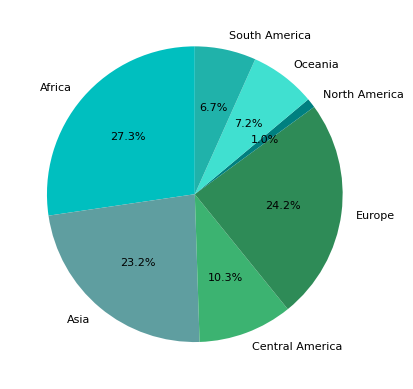

In [9]:
df_continentes = df_world.groupby("continent")["country"].count().reset_index()

colores = ["c", "cadetblue", "mediumseagreen", "seagreen", "teal", "turquoise", "lightseagreen"]

# creamos el gráfico basándonos en el DataFrame que hemos creado en el paso anterior
plt.pie("country", labels= "continent",
        data = df_continentes, 
        autopct=  '%1.1f%%', 
        colors = colores, 
        textprops={'fontsize': 8}, 
        startangle=90);

el continente con mayor numero de paises seria africa con un 27.3  en nuestro dataset, luego le sigue europa con un 24.2 y asia con un 23.2, estos serian los mayoritarios basntante igualados los 2 ultimos que hemos mencionado.


¿Cuáles son los 10 países con la mayor área forestal?

In [ ]:
df_world["forested_area"].sort_values(ascending=False) #ordenamos.

167    98.3
111    91.9
61     90.0
154    88.4
132    87.6
       ... 
113     NaN
120     NaN
128     NaN
133     NaN
163     NaN
Name: forested_area, Length: 195, dtype: float64

In [ ]:
sort_values()

In [19]:
top_paises=df_world["forested_area"].sort_values(ascending=False).head(10)


In [22]:
top_paises = df_world[["country", "forested_area"]].sort_values(by="forested_area", ascending=False).head(10)

C:\Users\Janira\AppData\Local\Temp\ipykernel_17516\403748040.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "forested_area",


<Axes: xlabel='forested_area', ylabel='country'>

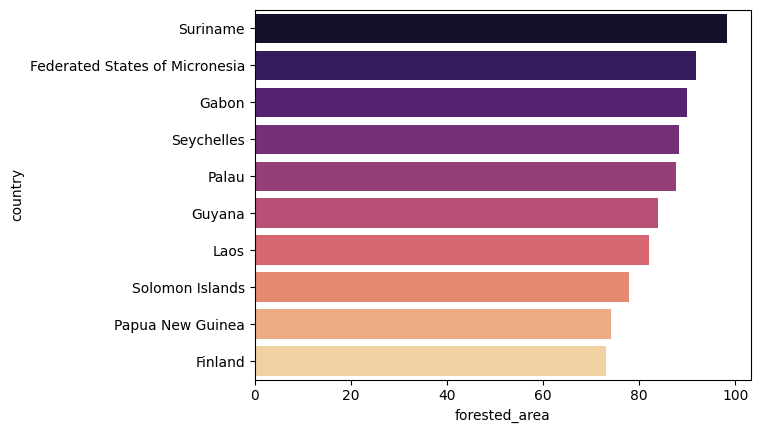

In [23]:
sns.barplot(x = "forested_area", 
            y = "country", 
            data = top_paises, 
            palette = "magma")

en primer lugar tenemos a suriname y le sigue el estado federal de micronesia, no hay grandes diferencias de uno a otro.

¿Cómo se distribuye la densidad de población entre los continentes?

<Axes: xlabel='density', ylabel='continent'>

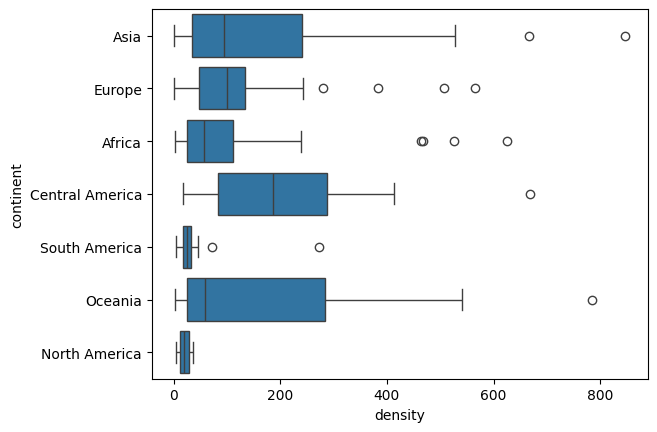

In [25]:
sns.boxplot(x="density", y="continent", data=df_world)

🧠 Lectura rápida por continentes
🌏 Asia
Mediana relativamente alta
Mucha dispersión
Outliers muy altos
👉 Cuadra: países como India o Bangladesh tienen densidades altísimas
🇪🇺 Europa
Densidad media-alta
Algunos outliers
👉 Tiene sentido (Países Bajos, Bélgica…)
🌍 África
Mediana más baja
Algunos valores extremos
👉 Normal: muchos países poco densos, pero otros muy concentrados
🌎 América Central
Bastante dispersión
👉 Países pequeños → variabilidad alta
🌎 América del Sur
Densidad baja en general
👉 Muy coherente (Brasil, Argentina…)
🌊 Oceanía
Muchísima dispersión + outliers
👉 Totalmente lógico: Australia (bajísima) vs microestados (altísima)
🇺🇸 América del Norte
Muy baja densidad
👉 Cuadra (Canadá pesa mucho en la media)


¿Existe una relación entre el PIB y la tasa de desempleo de los países?

In [27]:
df_world[["gdp","unemployment_rate"]]

,gdp,unemployment_rate
0,1.910135e+10,11.12
1,1.527808e+10,12.33
2,1.699882e+11,11.70
3,3.154058e+09,NaN
4,9.463542e+10,6.89
...,...,...
190,4.823593e+11,8.80
191,2.619212e+11,2.01
192,2.691440e+10,12.91
193,2.306472e+10,11.43


<Axes: xlabel='unemployment_rate', ylabel='gdp'>

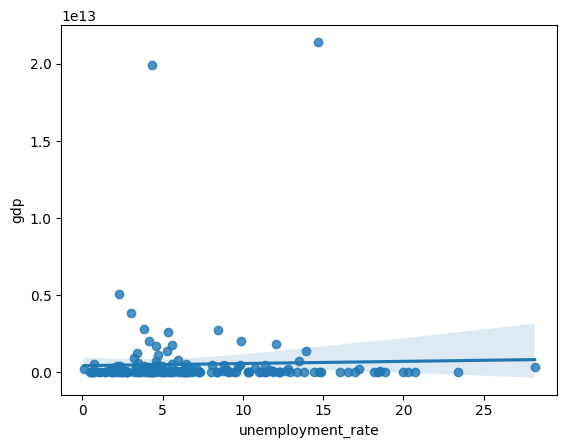

In [29]:
sns.regplot(
    data=df_world,
    x='unemployment_rate',
    y='gdp')

no hay relacion clara porque estan muy dispersos, no existe relacion.